Import Standard Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Import Machine Learning Libraries

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb

In [ ]:
# 3. Import Visualization & Interpretability
import shap

In [ ]:
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")
print("GPU Available!", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU Available! [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
! pip install kaggle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
! kaggle datasets download programmer3/additive-manufacturing-quality-control-dataset

Dataset URL: https://www.kaggle.com/datasets/programmer3/additive-manufacturing-quality-control-dataset
License(s): CC0-1.0
100% 202k/202k [00:00<00:00, 319kB/s]



In [ ]:
import zipfile
import os

# Define the path to the downloaded zip file
zip_file_path = '/content/additive-manufacturing-quality-control-dataset.zip'

# Define the directory where the contents will be extracted
extract_dir = '/content/additive-manufacturing-quality-control-dataset'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' unzipped to '{extract_dir}' successfully.")

'/content/additive-manufacturing-quality-control-dataset.zip' unzipped to '/content/additive-manufacturing-quality-control-dataset' successfully.


In [ ]:
# List the contents of the extracted directory
print("Contents of the extracted directory:")
for root, dirs, files in os.walk(extract_dir):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

Contents of the extracted directory:
/content/additive-manufacturing-quality-control-dataset/AM_Quality_Control_Data.csv


Load Data

In [ ]:
csv_file_path = os.path.join(extract_dir, 'AM_Quality_Control_Data.csv')
df = pd.read_csv(csv_file_path)
# Basic inspection
print(f"Shape: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"Data types:\n{df.dtypes}")
print(f"\nTarget distribution:\n{df['quality_label'].value_counts()}")
display(df.head())

Shape: (1480, 22)
Missing values:
layer_id                  0
segment_x                 0
segment_y                 0
temp_nozzle               0
feed_rate                 0
print_speed               0
extrusion_rate            0
chamber_temp              0
humidity                  0
vibration_level           0
layer_thickness           0
surface_roughness         0
deviation_z               0
temp_variance             0
graph_connectivity        0
attention_score           0
multi_hop_signal          0
quality_label             0
control_action          377
error_convergence         0
quality_score             0
dimensional_accuracy      0
dtype: int64
Data types:
layer_id                  int64
segment_x                 int64
segment_y                 int64
temp_nozzle             float64
feed_rate               float64
print_speed             float64
extrusion_rate          float64
chamber_temp            float64
humidity                float64
vibration_level         float64
layer

,layer_id,segment_x,segment_y,temp_nozzle,feed_rate,print_speed,extrusion_rate,chamber_temp,humidity,vibration_level,...,deviation_z,temp_variance,graph_connectivity,attention_score,multi_hop_signal,quality_label,control_action,error_convergence,quality_score,dimensional_accuracy
0,7,6,4,224.452785,1.302742,75.066359,107.452190,27.025304,23.106289,0.401516,...,-0.253189,0.440900,0.749189,0.677565,0.357279,Under-printed,Increase_Feed,5,75.32,3.50
1,4,2,6,222.690092,1.303772,74.500833,113.840039,42.451480,58.327865,0.429098,...,0.235422,1.684297,0.051516,0.102886,0.758721,Over-printed,Decrease_Feed,1,70.03,3.87
2,8,4,2,210.509056,1.657116,56.274447,98.769092,35.152734,55.960572,0.967800,...,-0.152139,1.988424,0.950099,0.474220,0.060598,Under-printed,Increase_Feed,2,62.75,2.80
3,5,2,6,207.535399,1.108932,51.665724,92.152815,41.159314,64.085634,0.723923,...,-0.261625,4.548548,0.702739,0.886755,0.917962,Under-printed,Increase_Feed,3,67.48,2.79
4,7,6,3,229.850491,1.364916,53.446458,113.254495,32.361713,51.978105,0.411788,...,0.022322,4.780040,0.320172,0.240910,0.171613,Over-printed,Decrease_Feed,2,77.29,3.74


Handling Missing Values & Data Types

In [ ]:
df['control_action'].fillna('Unknown', inplace=True)
print(f"Missing values after handling:\n{df.isnull().sum()}")

Missing values after handling:
layer_id                0
segment_x               0
segment_y               0
temp_nozzle             0
feed_rate               0
print_speed             0
extrusion_rate          0
chamber_temp            0
humidity                0
vibration_level         0
layer_thickness         0
surface_roughness       0
deviation_z             0
temp_variance           0
graph_connectivity      0
attention_score         0
multi_hop_signal        0
quality_label           0
control_action          0
error_convergence       0
quality_score           0
dimensional_accuracy    0
dtype: int64


/tmp/ipykernel_1620/367542988.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['control_action'].fillna('Unknown', inplace=True)


Encode Categorical Features

In [ ]:
label_encoder = LabelEncoder()
df['quality_label_encoded'] = label_encoder.fit_transform(df['quality_label'])
df['control_action_encoded'] = label_encoder.fit_transform(df['control_action'])

print(f"Data types after encoding:\n{df[['quality_label', 'quality_label_encoded', 'control_action', 'control_action_encoded']].dtypes}")
display(df[['quality_label', 'quality_label_encoded', 'control_action', 'control_action_encoded']].head())

Data types after encoding:
quality_label             object
quality_label_encoded      int64
control_action            object
control_action_encoded     int64
dtype: object


,quality_label,quality_label_encoded,control_action,control_action_encoded
0,Under-printed,3,Increase_Feed,1
1,Over-printed,2,Decrease_Feed,0
2,Under-printed,3,Increase_Feed,1
3,Under-printed,3,Increase_Feed,1
4,Over-printed,2,Decrease_Feed,0


### Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical features to scale
# Exclude 'layer_id', 'quality_label_encoded', and 'control_action_encoded' as they are either identifiers or already encoded.
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
numerical_features.remove('layer_id')
numerical_features.remove('quality_label_encoded')
numerical_features.remove('control_action_encoded')

print(f"Numerical features to scale: {numerical_features}")

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the selected numerical features
df[numerical_features] = scaler.fit_transform(df[numerical_features])

print("\nFirst 5 rows after feature scaling:")
display(df[numerical_features].head())

Numerical features to scale: ['segment_x', 'segment_y', 'temp_nozzle', 'feed_rate', 'print_speed', 'extrusion_rate', 'chamber_temp', 'humidity', 'vibration_level', 'layer_thickness', 'surface_roughness', 'deviation_z', 'temp_variance', 'graph_connectivity', 'attention_score', 'multi_hop_signal', 'error_convergence', 'quality_score', 'dimensional_accuracy']

First 5 rows after feature scaling:


,segment_x,segment_y,temp_nozzle,feed_rate,print_speed,extrusion_rate,chamber_temp,humidity,vibration_level,layer_thickness,surface_roughness,deviation_z,temp_variance,graph_connectivity,attention_score,multi_hop_signal,error_convergence,quality_score,dimensional_accuracy
0,1.437012,0.305620,1.272341,-1.174832,1.445677,0.836645,-1.405764,-1.501804,-0.356076,-0.616594,0.788599,-1.451570,-1.394903,0.865580,0.606083,-0.502723,1.440980,-0.017620,0.576195
1,-0.908483,1.477428,1.118730,-1.173060,1.412784,1.569507,1.300598,0.938422,-0.259064,-0.530214,1.347200,1.412307,-0.541988,-1.554764,-1.380216,0.879774,-1.389346,-0.478339,0.895917
2,0.264264,-0.866188,0.057204,-0.565193,0.352702,-0.159546,0.020109,0.774411,1.635691,-1.007596,1.470893,-0.859293,-0.333370,1.562571,-0.096752,-1.524442,-0.681764,-1.112373,-0.028685
3,-0.908483,1.477428,-0.201937,-1.508250,0.084649,-0.918615,1.073901,1.337332,0.777911,-0.190376,0.039151,-1.501018,1.422763,0.704440,1.329120,1.428173,0.025817,-0.700425,-0.037326
4,1.437012,-0.280284,1.742729,-1.067873,0.188220,1.502329,-0.469547,0.498497,-0.319948,-1.546329,0.452058,0.163271,1.581556,-0.622749,-0.903156,-1.142126,-0.681764,0.153952,0.783582


### Outlier Detection & Handling

Interquartile Range (IQR) Method

*   **Lower Fence:** `Q1 - 1.5 * IQR`
*   **Upper Fence:** `Q3 + 1.5 * IQR`

In [ ]:
# Identify and handle outliers using the IQR method for all numerical features

for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap the outliers (Winsorization) rather than removing them to preserve data
    df[feature] = np.where(df[feature] < lower_bound, lower_bound, df[feature])
    df[feature] = np.where(df[feature] > upper_bound, upper_bound, df[feature])

    print(f"Feature '{feature}': Outliers capped between {lower_bound:.2f} and {upper_bound:.2f}")

print("\nFirst 5 rows after outlier handling (capping):")
display(df[numerical_features].head())

Feature 'segment_x': Outliers capped between -3.55 and 3.49
Feature 'segment_y': Outliers capped between -3.50 and 3.53
Feature 'temp_nozzle': Outliers capped between -3.43 and 3.46
Feature 'feed_rate': Outliers capped between -3.49 and 3.49
Feature 'print_speed': Outliers capped between -3.36 and 3.37
Feature 'extrusion_rate': Outliers capped between -3.41 and 3.45
Feature 'chamber_temp': Outliers capped between -3.34 and 3.36
Feature 'humidity': Outliers capped between -3.38 and 3.40
Feature 'vibration_level': Outliers capped between -3.40 and 3.39
Feature 'layer_thickness': Outliers capped between -3.47 and 3.46
Feature 'surface_roughness': Outliers capped between -3.31 and 3.30
Feature 'deviation_z': Outliers capped between -3.49 and 3.43
Feature 'temp_variance': Outliers capped between -3.45 and 3.45
Feature 'graph_connectivity': Outliers capped between -3.46 and 3.47
Feature 'attention_score': Outliers capped between -3.47 and 3.51
Feature 'multi_hop_signal': Outliers capped betw

,segment_x,segment_y,temp_nozzle,feed_rate,print_speed,extrusion_rate,chamber_temp,humidity,vibration_level,layer_thickness,surface_roughness,deviation_z,temp_variance,graph_connectivity,attention_score,multi_hop_signal,error_convergence,quality_score,dimensional_accuracy
0,1.437012,0.305620,1.272341,-1.174832,1.445677,0.836645,-1.405764,-1.501804,-0.356076,-0.616594,0.788599,-1.451570,-1.394903,0.865580,0.606083,-0.502723,1.440980,-0.017620,0.576195
1,-0.908483,1.477428,1.118730,-1.173060,1.412784,1.569507,1.300598,0.938422,-0.259064,-0.530214,1.347200,1.412307,-0.541988,-1.554764,-1.380216,0.879774,-1.389346,-0.478339,0.895917
2,0.264264,-0.866188,0.057204,-0.565193,0.352702,-0.159546,0.020109,0.774411,1.635691,-1.007596,1.470893,-0.859293,-0.333370,1.562571,-0.096752,-1.524442,-0.681764,-1.112373,-0.028685
3,-0.908483,1.477428,-0.201937,-1.508250,0.084649,-0.918615,1.073901,1.337332,0.777911,-0.190376,0.039151,-1.501018,1.422763,0.704440,1.329120,1.428173,0.025817,-0.700425,-0.037326
4,1.437012,-0.280284,1.742729,-1.067873,0.188220,1.502329,-0.469547,0.498497,-0.319948,-1.546329,0.452058,0.163271,1.581556,-0.622749,-0.903156,-1.142126,-0.681764,0.153952,0.783582


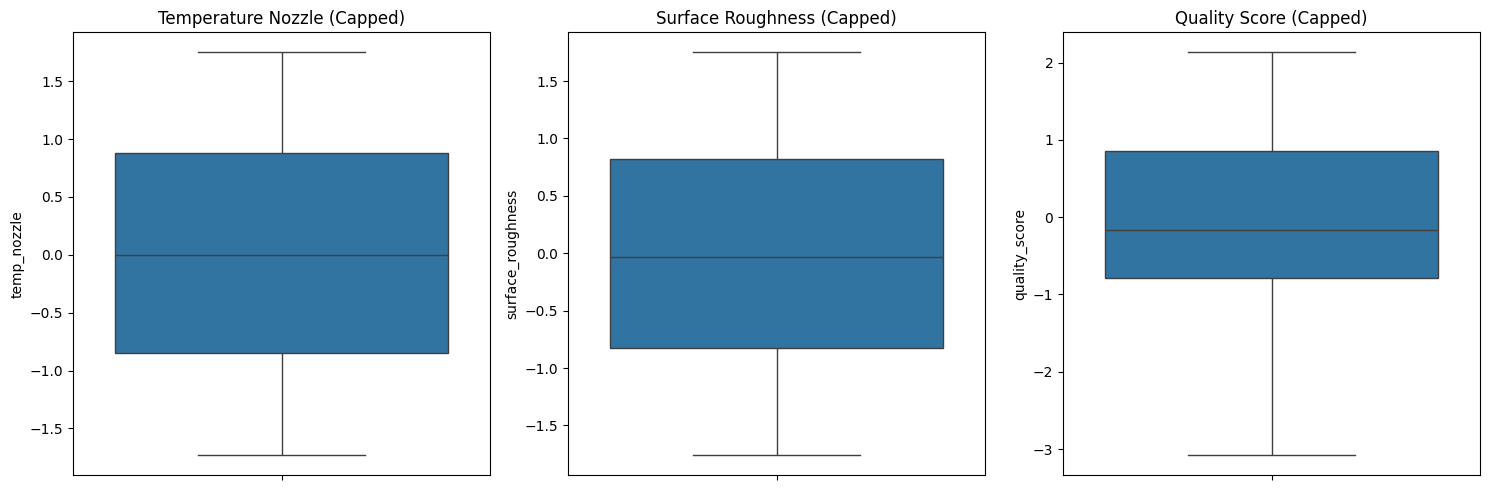

In [ ]:
# Visualize some key features after outlier capping

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['temp_nozzle'])
plt.title('Temperature Nozzle (Capped)')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['surface_roughness'])
plt.title('Surface Roughness (Capped)')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['quality_score'])
plt.title('Quality Score (Capped)')

plt.tight_layout()
plt.show()

### Addressing Class Imbalance
Synthetic Minority Over-sampling Technique (SMOTE)

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Define features (X) and target (y)
X = df.drop(columns=['quality_label', 'control_action', 'quality_label_encoded'])
y = df['quality_label_encoded']

print(f"Original target distribution: {Counter(y)}")

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Resampled target distribution: {Counter(y_resampled)}")

# Update the DataFrame or keep X_resampled, y_resampled for model training

Original target distribution: Counter({3: 626, 2: 454, 1: 377, 0: 23})
Resampled target distribution: Counter({3: 626, 2: 626, 1: 626, 0: 626})


### Train-Test Split with Stratification

In [ ]:
# Perform train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print(f"\nOriginal target distribution in y_resampled: {Counter(y_resampled)}")
print(f"Target distribution in y_train: {Counter(y_train)}")
print(f"Target distribution in y_test: {Counter(y_test)}")

X_train shape: (2003, 21)
X_test shape: (501, 21)
y_train shape: (2003,)
y_test shape: (501,)

Original target distribution in y_resampled: Counter({3: 626, 2: 626, 1: 626, 0: 626})
Target distribution in y_train: Counter({3: 501, 1: 501, 0: 501, 2: 500})
Target distribution in y_test: Counter({2: 126, 1: 125, 0: 125, 3: 125})


### Feature Correlation

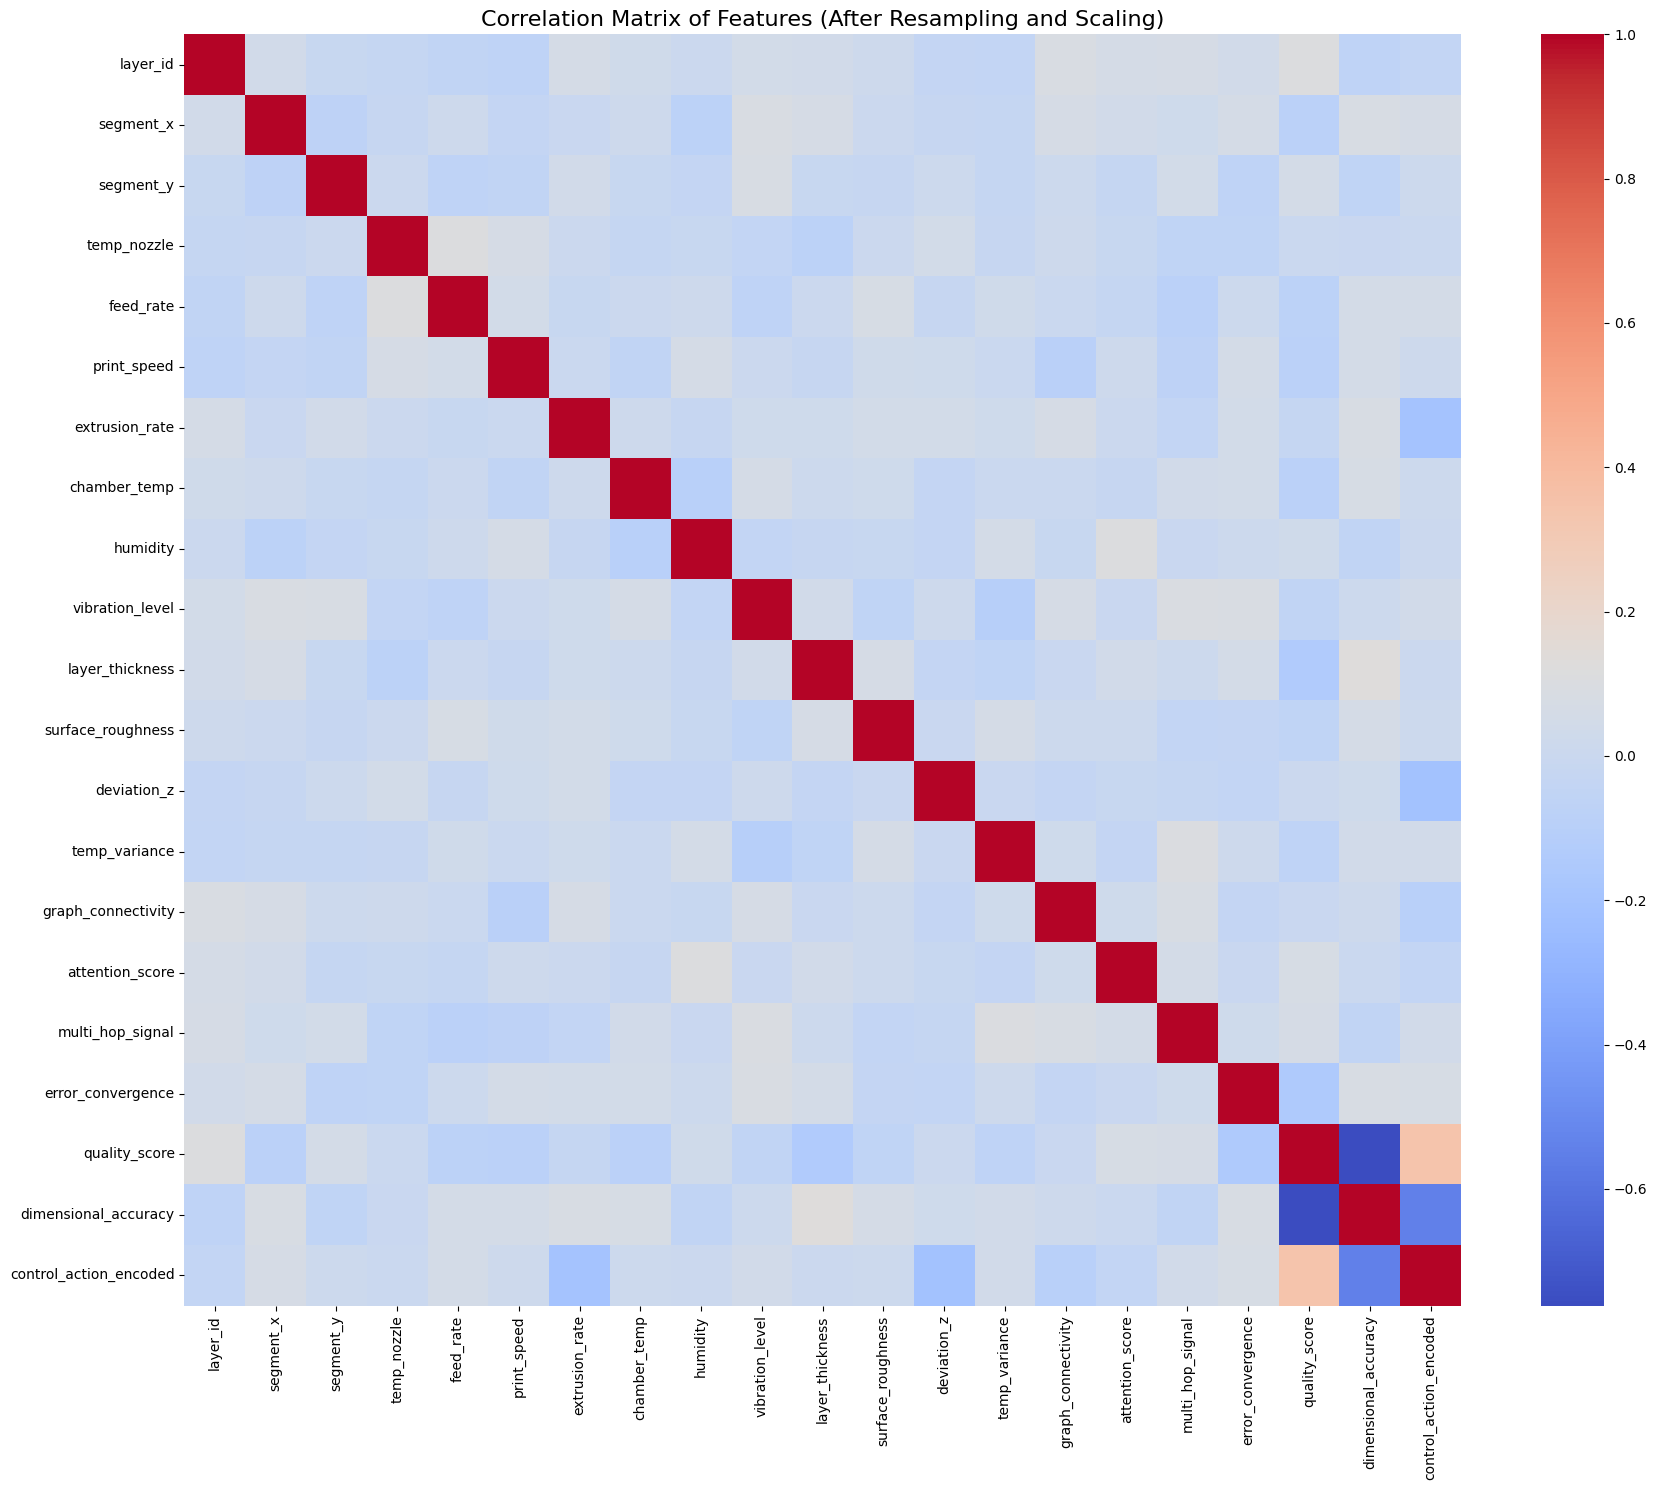

In [ ]:
plt.figure(figsize=(18, 15))
sns.heatmap(X_resampled.corr(), annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features (After Resampling and Scaling)', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Preprocessing Pipeline

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

# Custom Outlier Capper Transformer (adapted for numpy arrays output by StandardScaler)
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_bounds = None
        self.upper_bounds = None

    def fit(self, X, y=None):
        # X will be a numpy array from StandardScaler. Calculate bounds column-wise.
        if not isinstance(X, np.ndarray):
            X = np.asarray(X)
        Q1 = np.percentile(X, 25, axis=0)
        Q3 = np.percentile(X, 75, axis=0)
        IQR = Q3 - Q1
        self.lower_bounds = Q1 - self.factor * IQR
        self.upper_bounds = Q3 + self.factor * IQR
        return self

    def transform(self, X, y=None):
        # X will be a numpy array. Apply capping column-wise.
        if not isinstance(X, np.ndarray):
            X = np.asarray(X)
        X_transformed = np.copy(X)
        for i in range(X.shape[1]):
            X_transformed[:, i] = np.where(X_transformed[:, i] < self.lower_bounds[i], self.lower_bounds[i], X_transformed[:, i])
            X_transformed[:, i] = np.where(X_transformed[:, i] > self.upper_bounds[i], self.upper_bounds[i], X_transformed[:, i])
        return X_transformed


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
import pandas as pd

# Define column types from the *original* dataframe perspective
# These lists specify which columns the preprocessor should operate on.
# 'quality_label' and 'quality_label_encoded' are target variables and not included in features for the pipeline.
numerical_cols = ['segment_x', 'segment_y', 'temp_nozzle', 'feed_rate', 'print_speed', 'extrusion_rate',
                  'chamber_temp', 'humidity', 'vibration_level', 'layer_thickness', 'surface_roughness',
                  'deviation_z', 'temp_variance', 'graph_connectivity', 'attention_score', 'multi_hop_signal',
                  'error_convergence', 'quality_score', 'dimensional_accuracy']
categorical_cols = ['control_action']
passthrough_cols = ['layer_id'] # Columns to keep as-is without transformation

# Numerical features pipeline: scale then cap outliers
numerical_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('outlier_capper', OutlierCapper())
])

# Categorical features pipeline: impute 'Unknown' then encode using OrdinalEncoder
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Create the full preprocessor using ColumnTransformer
# It will apply the specified transformations to the correct columns
# and pass through 'layer_id' without transformation.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ],
    remainder='passthrough', # This ensures 'layer_id' is included in the output and placed at the end
    verbose_feature_names_out=False # To get cleaner feature names in the output
)

print("Preprocessing pipeline created successfully!")
print(preprocessor)


Preprocessing pipeline created successfully!
ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler()),
                                                 ('outlier_capper',
                                                  OutlierCapper())]),
                                 ['segment_x', 'segment_y', 'temp_nozzle',
                                  'feed_rate', 'print_speed', 'extrusion_rate',
                                  'chamber_temp', 'humidity', 'vibration_level',
                                  'layer_thickness', 'surface_roughness',
                                  'deviation_z', 'temp_variance',
                                  'graph_connectivity', 'attention_score',
                                  'multi_hop_signal', 'error_convergence',
                                  'quality_score', 'dimensional_accuracy']),
                                ('cat',
            

### Physics-Informed Features
**1. Thermal Gradient**

*   **Formula:** `thermal_gradient = (temp_nozzle - chamber_temp) / layer_thickness`
*   **Units:** °C/mm
*   **Physics:** Represents the temperature differential driving heat transfer through the deposited material layer;

In [ ]:
# Calculate thermal_gradient
df['thermal_gradient'] = (df['temp_nozzle'] - df['chamber_temp']) / df['layer_thickness']

print("DataFrame with 'thermal_gradient' feature:")
display(df[['temp_nozzle', 'chamber_temp', 'layer_thickness', 'thermal_gradient']].head())

DataFrame with 'thermal_gradient' feature:


,temp_nozzle,chamber_temp,layer_thickness,thermal_gradient
0,1.272341,-1.405764,-0.616594,-4.343383
1,1.118730,1.300598,-0.530214,0.343009
2,0.057204,0.020109,-1.007596,-0.036816
3,-0.201937,1.073901,-0.190376,6.701677
4,1.742729,-0.469547,-1.546329,-1.430663


**2. Extrusion Balance**

*   **Formula:** `extrusion_balance = extrusion_rate / (feed_rate × print_speed × layer_thickness)`
*   **Units:** Dimensionless (ideal ≈ 1.0)
*   **Physics:** Compares actual volumetric extrusion to the theoretical volume required for the commanded path; <1 under-extrusion (voids, weak layers);  >1  over-extrusion (oozing, dimensional inaccuracy);

In [ ]:
# Calculate extrusion_balance
df['extrusion_balance'] = df['extrusion_rate'] / (df['feed_rate'] * df['print_speed'] * df['layer_thickness'])

print("DataFrame with 'extrusion_balance' feature:")
display(df[['extrusion_rate', 'feed_rate', 'print_speed', 'layer_thickness', 'extrusion_balance']].head())

DataFrame with 'extrusion_balance' feature:


,extrusion_rate,feed_rate,print_speed,layer_thickness,extrusion_balance
0,0.836645,-1.174832,1.445677,-0.616594,0.798904
1,1.569507,-1.173060,1.412784,-0.530214,1.786139
2,-0.159546,-0.565193,0.352702,-1.007596,-0.794318
3,-0.918615,-1.508250,0.084649,-0.190376,-37.794275
4,1.502329,-1.067873,0.188220,-1.546329,4.833675


**3. Geometric Thermal Coupling**

*   **Formula:** `geometric_thermal_coupling = deviation_z × (temp_nozzle - chamber_temp)`
*   **Units:** mm·°C
*   **Physics:** Captures the interaction between thermal conditions and Z-axis dimensional errors; Large positive/negative values (thermally-induced warping, shrinkage, or bed adhesion issues); key predictors for dimensional_accuracy;

In [ ]:
# Calculate geometric_thermal_coupling
df['geometric_thermal_coupling'] = df['deviation_z'] * (df['temp_nozzle'] - df['chamber_temp'])

print("DataFrame with 'geometric_thermal_coupling' feature:")
display(df[['deviation_z', 'temp_nozzle', 'chamber_temp', 'geometric_thermal_coupling']].head())

DataFrame with 'geometric_thermal_coupling' feature:


,deviation_z,temp_nozzle,chamber_temp,geometric_thermal_coupling
0,-1.451570,1.272341,-1.405764,-3.887457
1,1.412307,1.118730,1.300598,-0.256854
2,-0.859293,0.057204,0.020109,-0.031876
3,-1.501018,-0.201937,1.073901,1.915057
4,0.163271,1.742729,-0.469547,0.361201


**4. Process Stability Index**

*   **Formula:** `process_stability_index = 1 / (temp_variance × vibration_level + ε)` (`ε = 1e-6` for numerical stability)
*   **Units:** Inverse of (°C² × acceleration)
*   **Physics:** Quantifies susceptibility to process disturbances; High thermal variance with mechanical vibration promotes geometric errors and surface defects;

In [ ]:
# Calculate process_stability_index
df['process_stability_index'] = 1 / (df['temp_variance'] * df['vibration_level'] + 1e-6)

print("DataFrame with 'process_stability_index' feature:")
display(df[['temp_variance', 'vibration_level', 'process_stability_index']].head())

DataFrame with 'process_stability_index' feature:


,temp_variance,vibration_level,process_stability_index
0,-1.394903,-0.356076,2.013319
1,-0.541988,-0.259064,7.121960
2,-0.333370,1.635691,-1.833887
3,1.422763,0.777911,0.903519
4,1.581556,-0.319948,-1.976225


**5. Linear Energy Input**

*   **Formula:** `linear_energy_input = temp_nozzle × feed_rate / print_speed`
*   **Units:** °C·mm²/s (proxy for energy per unit length)
*   **Physics:** Approximates heat input per unit travel distance; Governs melt pool viscosity, polymer chain entanglement across layers, and cooling kinetics;

In [ ]:
# Calculate linear_energy_input
df['linear_energy_input'] = (df['temp_nozzle'] * df['feed_rate']) / df['print_speed']

print("DataFrame with 'linear_energy_input' feature:")
display(df[['temp_nozzle', 'feed_rate', 'print_speed', 'linear_energy_input']].head())

DataFrame with 'linear_energy_input' feature:


,temp_nozzle,feed_rate,print_speed,linear_energy_input
0,1.272341,-1.174832,1.445677,-1.033971
1,1.118730,-1.173060,1.412784,-0.928902
2,0.057204,-0.565193,0.352702,-0.091668
3,-0.201937,-1.508250,0.084649,3.598055
4,1.742729,-1.067873,0.188220,-9.887433


**Re-defining Features and Target after Feature Engineering**

In [ ]:
# Define features (X) and target (y) again, now excluding the identified leaking features
X = df.drop(columns=['quality_label', 'control_action', 'quality_label_encoded', 'quality_score', 'dimensional_accuracy'])
y = df['quality_label_encoded']

print(f"Original target distribution: {Counter(y)}")

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Resampled target distribution: {Counter(y_resampled)}")

# Perform train-test split with stratification on the new resampled data
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print(f"\nOriginal target distribution in y_resampled: {Counter(y_resampled)}")
print(f"Target distribution in y_train: {Counter(y_train)}")
print(f"Target distribution in y_test: {Counter(y_test)}")

Original target distribution: Counter({3: 626, 2: 454, 1: 377, 0: 23})
Resampled target distribution: Counter({3: 626, 2: 626, 1: 626, 0: 626})

X_train shape: (2003, 24)
X_test shape: (501, 24)
y_train shape: (2003,)
y_test shape: (501,)

Original target distribution in y_resampled: Counter({3: 626, 2: 626, 1: 626, 0: 626})
Target distribution in y_train: Counter({3: 501, 1: 501, 0: 501, 2: 500})
Target distribution in y_test: Counter({2: 126, 1: 125, 0: 125, 3: 125})


### Model Training: Random Forest Classifier

In [ ]:
# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # Use class_weight for potentially better handling of any residual imbalance
rf_model.fit(X_train, y_train)

print("Random Forest Classifier trained successfully!")

Random Forest Classifier trained successfully!


### Evaluation

Aaccuracy; precision; recall; and F1-score; Confution Matrix


--- Model Evaluation ---
Accuracy: 1.0000

Classification Report:
                precision    recall  f1-score   support

 Decrease_Feed       1.00      1.00      1.00       125
 Increase_Feed       1.00      1.00      1.00       125
Increase_Speed       1.00      1.00      1.00       126
       Unknown       1.00      1.00      1.00       125

      accuracy                           1.00       501
     macro avg       1.00      1.00      1.00       501
  weighted avg       1.00      1.00      1.00       501


Confusion Matrix:


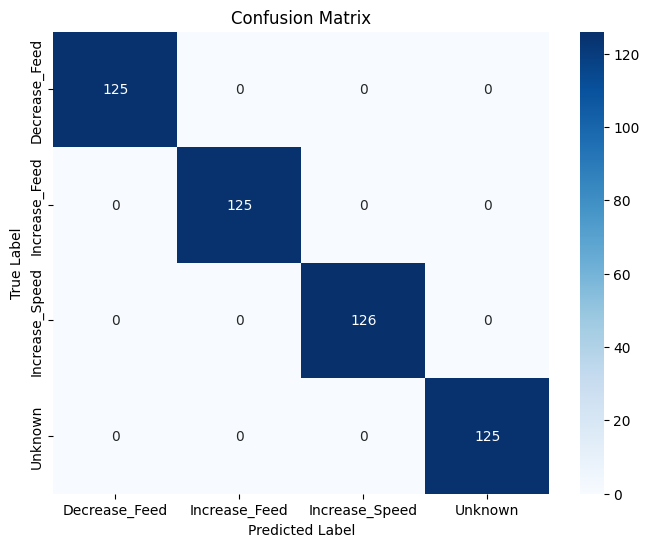

In [ ]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

**Feature Importance**


--- Top 10 Feature Importances ---
                       feature  importance
20      control_action_encoded    0.325554
18               quality_score    0.242066
19        dimensional_accuracy    0.160301
12                 deviation_z    0.117583
6               extrusion_rate    0.096959
23  geometric_thermal_coupling    0.012089
17           error_convergence    0.005792
21            thermal_gradient    0.005666
7                 chamber_temp    0.005483
3                  temp_nozzle    0.003794


/tmp/ipykernel_1620/2195747796.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances.head(20), palette='viridis')


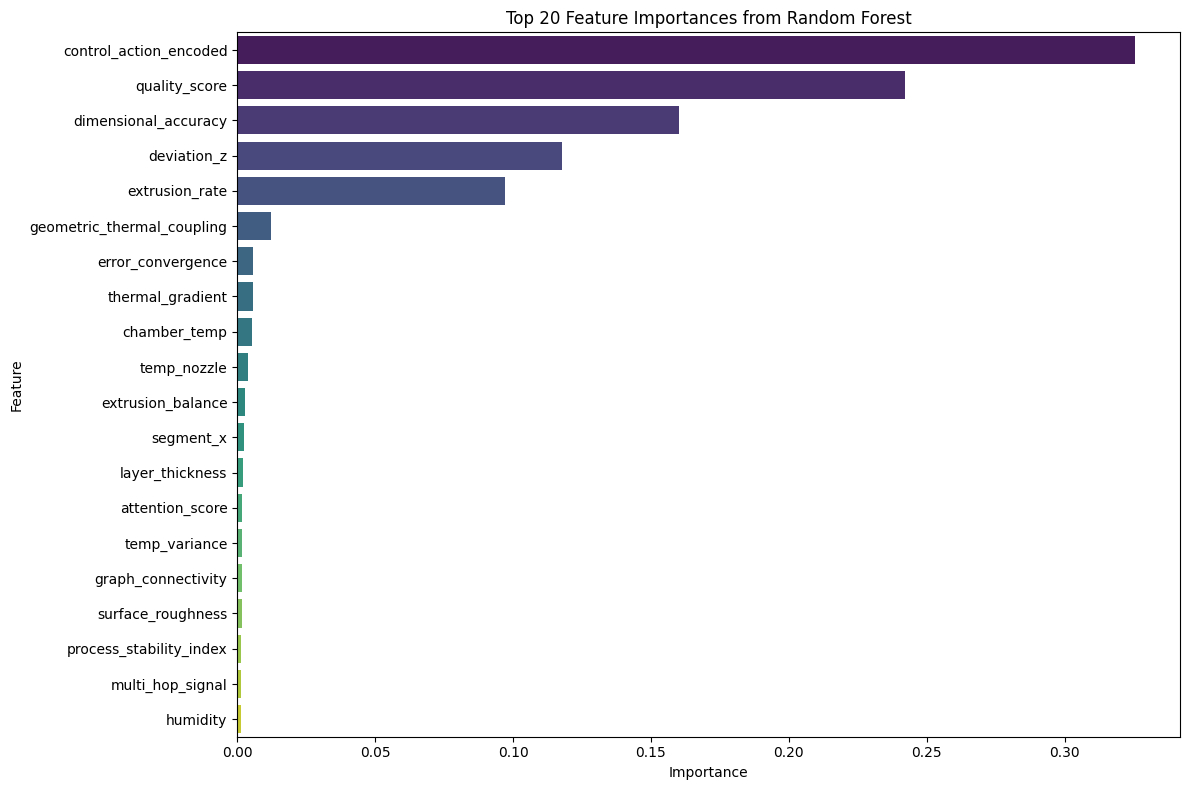

In [ ]:
# Get feature importances
feature_importances = pd.DataFrame({'feature': X_train.columns, 'importance': rf_model.feature_importances_})
feature_importances = feature_importances.sort_values('importance', ascending=False)

# Display top N important features
print("\n--- Top 10 Feature Importances ---")
print(feature_importances.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances.head(20), palette='viridis')
plt.title('Top 20 Feature Importances from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Addressing Data Leakage: Re-training without Leaking Features**

In [ ]:
# Redefine features (X) and target (y) by dropping the identified leaking features
X_leak_removed = df.drop(columns=['quality_label', 'control_action', 'quality_label_encoded', 'quality_score', 'dimensional_accuracy', 'control_action_encoded'])
y_leak_removed = df['quality_label_encoded']

print(f"Original target distribution (after removing leaking features): {Counter(y_leak_removed)}")

# Initialize SMOTE
smote_new = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_resampled_new, y_resampled_new = smote_new.fit_resample(X_leak_removed, y_leak_removed)

print(f"Resampled target distribution (after removing leaking features): {Counter(y_resampled_new)}")

# Perform train-test split with stratification on the new resampled data
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_resampled_new, y_resampled_new, test_size=0.2, random_state=42, stratify=y_resampled_new)

print(f"\nX_train_new shape: {X_train_new.shape}")
print(f"X_test_new shape: {X_test_new.shape}")
print(f"y_train_new shape: {y_train_new.shape}")
print(f"y_test_new shape: {y_test_new.shape}")

print(f"\nTarget distribution in y_train_new: {Counter(y_train_new)}")
print(f"Target distribution in y_test_new: {Counter(y_test_new)}")

Original target distribution (after removing leaking features): Counter({3: 626, 2: 454, 1: 377, 0: 23})
Resampled target distribution (after removing leaking features): Counter({3: 626, 2: 626, 1: 626, 0: 626})

X_train_new shape: (2003, 23)
X_test_new shape: (501, 23)
y_train_new shape: (2003,)
y_test_new shape: (501,)

Target distribution in y_train_new: Counter({3: 501, 1: 501, 0: 501, 2: 500})
Target distribution in y_test_new: Counter({2: 126, 1: 125, 0: 125, 3: 125})


### Re-training the Random Forest Classifier (w/o leaking features)

In [ ]:
# Initialize and train the Random Forest Classifier with the new dataset
rf_model_new = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model_new.fit(X_train_new, y_train_new)

print("Random Forest Classifier re-trained successfully (without leaking features)!")

Random Forest Classifier re-trained successfully (without leaking features)!


### Re-evaluating the Model (w/o leaking features)


--- Model Re-Evaluation (without leaking features) ---
Accuracy: 0.9960

Classification Report:
                precision    recall  f1-score   support

 Decrease_Feed       1.00      1.00      1.00       125
 Increase_Feed       0.98      1.00      0.99       125
Increase_Speed       1.00      0.98      0.99       126
       Unknown       1.00      1.00      1.00       125

      accuracy                           1.00       501
     macro avg       1.00      1.00      1.00       501
  weighted avg       1.00      1.00      1.00       501


Confusion Matrix:


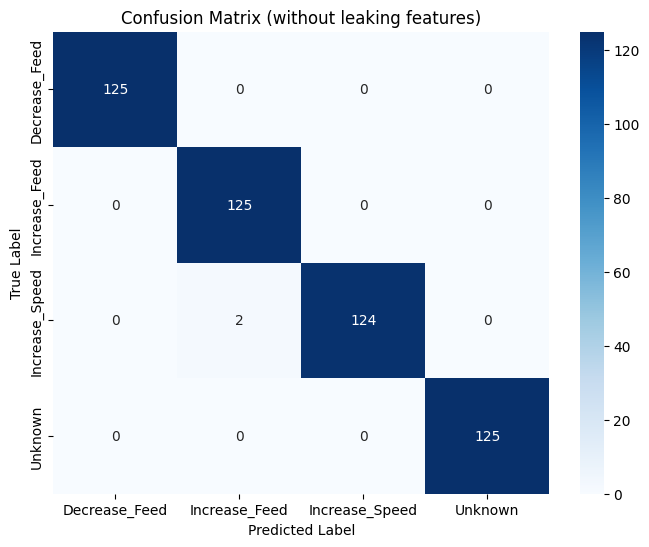

In [ ]:
# Make predictions on the new test set
y_pred_new = rf_model_new.predict(X_test_new)

# Evaluate the model
print("\n--- Model Re-Evaluation (without leaking features) ---")
print(f"Accuracy: {accuracy_score(y_test_new, y_pred_new):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_new, y_pred_new, target_names=label_encoder.classes_))

print("\nConfusion Matrix:")
cm_new = confusion_matrix(y_test_new, y_pred_new)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (without leaking features)')
plt.show()

### Re-examining Feature Importance (without leaking features)

**Model Training: Gradient Boosting Classifier**

In [ ]:
# Initialize and train the Gradient Boosting Classifier
gbc_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gbc_model.fit(X_train_new, y_train_new)

print("Gradient Boosting Classifier trained successfully!")

Gradient Boosting Classifier trained successfully!


**Model Evaluation (Gradient Boosting Classifier)**


--- Gradient Boosting Model Evaluation ---
Accuracy: 0.9840

Classification Report:
                precision    recall  f1-score   support

 Decrease_Feed       0.98      0.97      0.98       125
 Increase_Feed       0.95      0.98      0.97       125
Increase_Speed       1.00      0.98      0.99       126
       Unknown       1.00      1.00      1.00       125

      accuracy                           0.98       501
     macro avg       0.98      0.98      0.98       501
  weighted avg       0.98      0.98      0.98       501


Confusion Matrix:


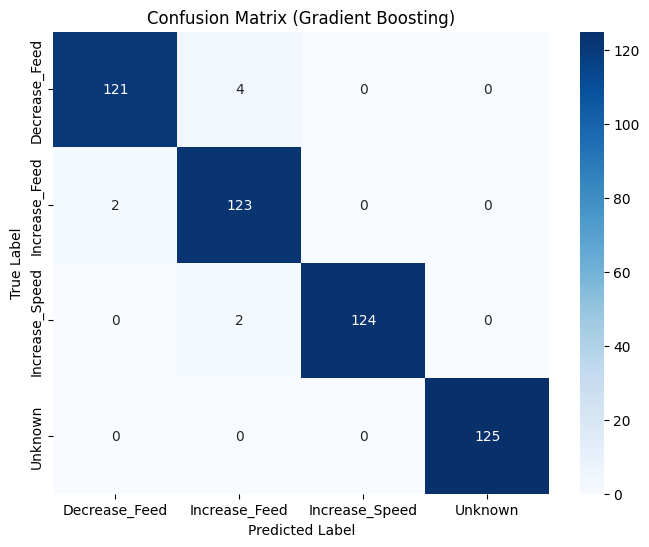

In [ ]:
# Make predictions on the test set
y_pred_gbc = gbc_model.predict(X_test_new)

# Evaluate the model
print("\n--- Gradient Boosting Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test_new, y_pred_gbc):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_new, y_pred_gbc, target_names=label_encoder.classes_))

print("\nConfusion Matrix:")
cm_gbc = confusion_matrix(y_test_new, y_pred_gbc)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gbc, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Gradient Boosting)')
plt.show()

**Feature Importance (Gradient Boosting Classifier)**


--- Top 10 Feature Importances (Gradient Boosting) ---
              feature  importance
12        deviation_z    0.426675
6      extrusion_rate    0.387809
17  error_convergence    0.030157
18   thermal_gradient    0.019749
19  extrusion_balance    0.010854
13      temp_variance    0.010778
7        chamber_temp    0.010755
8            humidity    0.010243
10    layer_thickness    0.010188
5         print_speed    0.010057


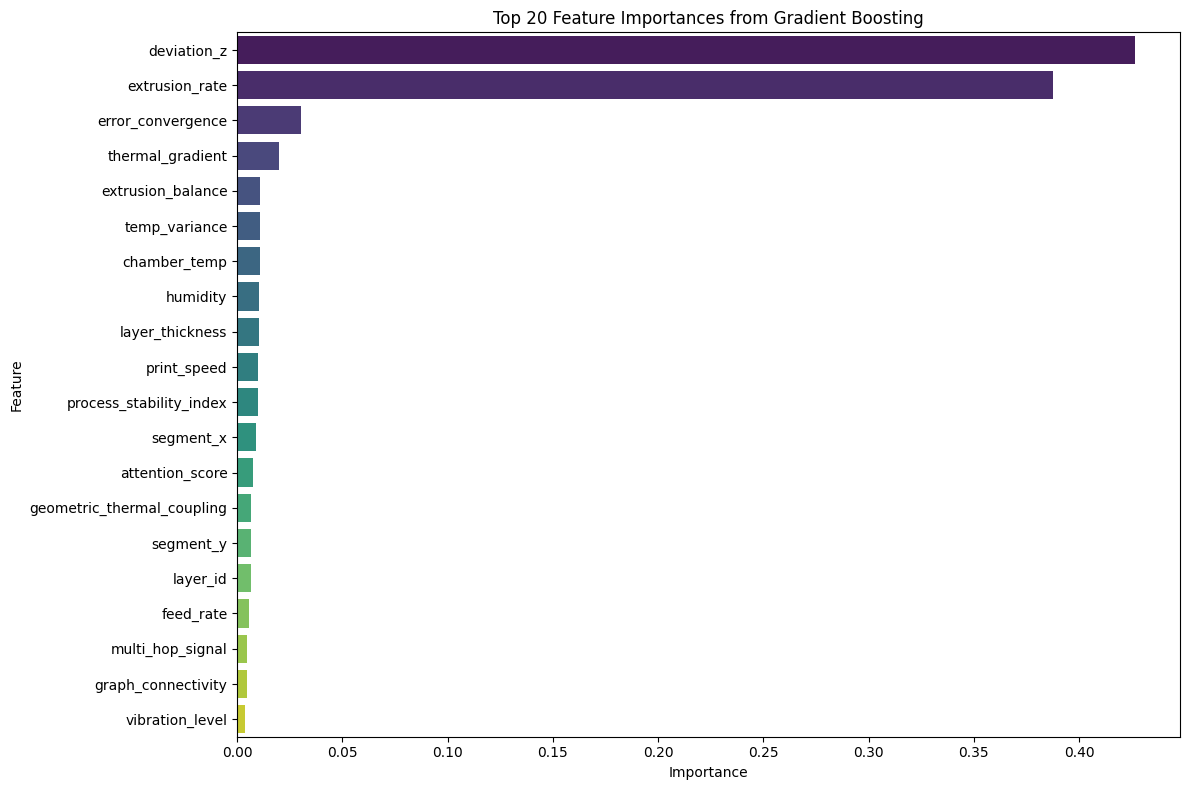

In [ ]:
# Get feature importances for the Gradient Boosting model
feature_importances_gbc = pd.DataFrame({'feature': X_train_new.columns, 'importance': gbc_model.feature_importances_})
feature_importances_gbc = feature_importances_gbc.sort_values('importance', ascending=False)

# Display top N important features
print("\n--- Top 10 Feature Importances (Gradient Boosting) ---")
print(feature_importances_gbc.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', hue='feature', data=feature_importances_gbc.head(20), palette='viridis', legend=False)
plt.title('Top 20 Feature Importances from Gradient Boosting')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


--- Top 10 Feature Importances (without leaking features) ---
                       feature  importance
12                 deviation_z    0.220611
6               extrusion_rate    0.218087
20  geometric_thermal_coupling    0.059923
17           error_convergence    0.034159
18            thermal_gradient    0.033581
7                 chamber_temp    0.031809
19           extrusion_balance    0.030839
3                  temp_nozzle    0.029673
10             layer_thickness    0.029612
5                  print_speed    0.028883


/tmp/ipykernel_1620/1433421411.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances_new.head(20), palette='viridis')


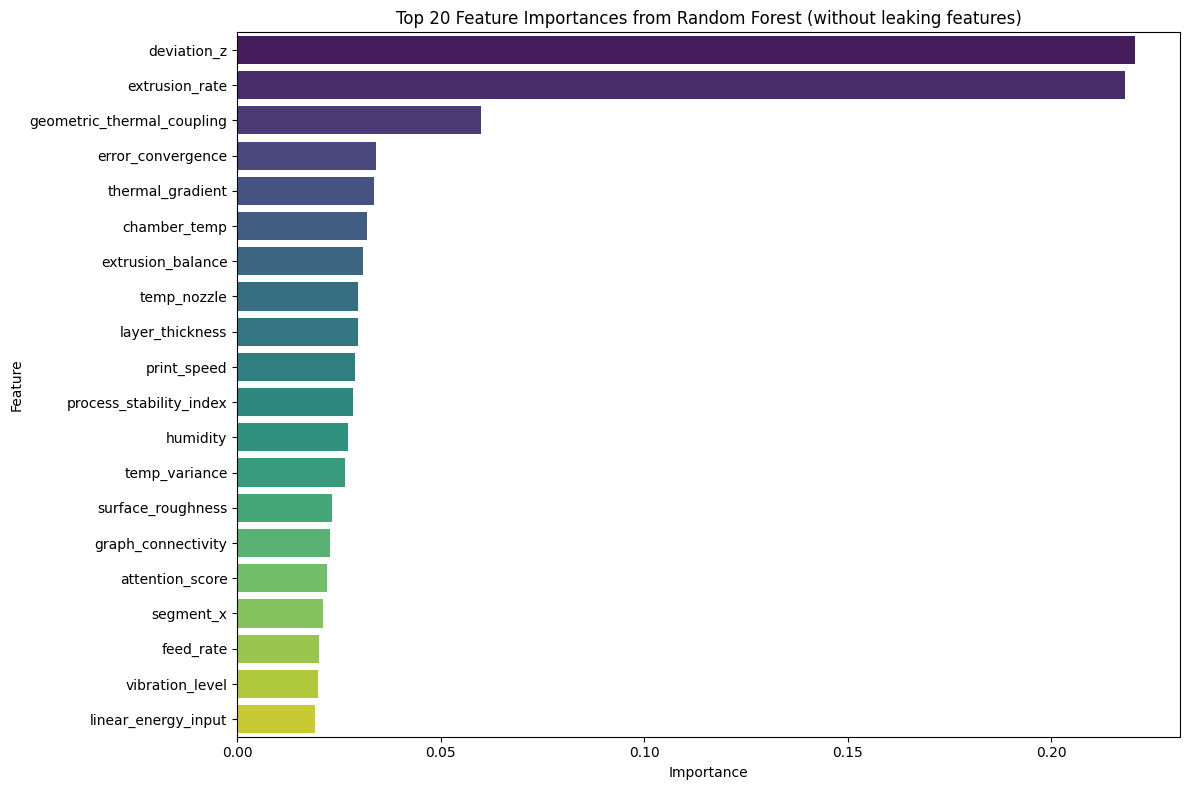

In [ ]:
# Get feature importances for the new model
feature_importances_new = pd.DataFrame({'feature': X_train_new.columns, 'importance': rf_model_new.feature_importances_})
feature_importances_new = feature_importances_new.sort_values('importance', ascending=False)

# Display top N important features
print("\n--- Top 10 Feature Importances (without leaking features) ---")
print(feature_importances_new.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances_new.head(20), palette='viridis')
plt.title('Top 20 Feature Importances from Random Forest (without leaking features)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Initialize SHAP to interpreate**

In [ ]:
# Initialize JS for SHAP plots
shap.initjs()

# SHAP explainer object for the Random Forest model
explainer = shap.TreeExplainer(rf_model_new)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_new)

print("SHAP explainer initialized and SHAP values calculated successfully!")

SHAP explainer initialized and SHAP values calculated successfully!


**SHAP Summary**


SHAP Summary Plot for Class: Decrease_Feed


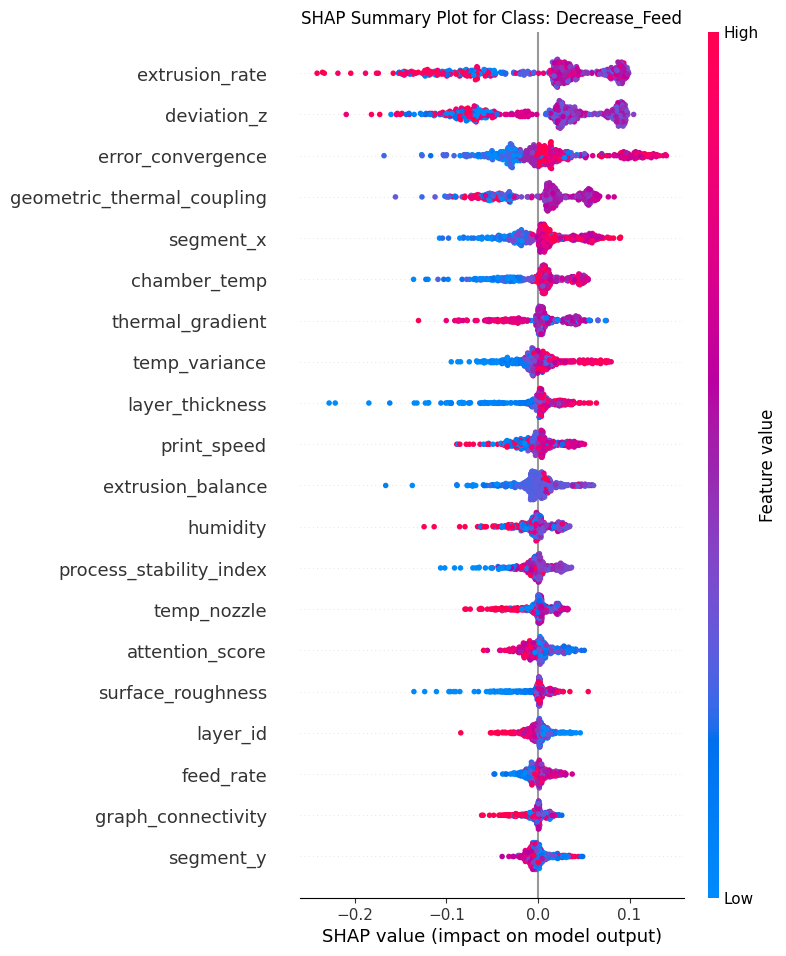


SHAP Summary Plot for Class: Increase_Feed


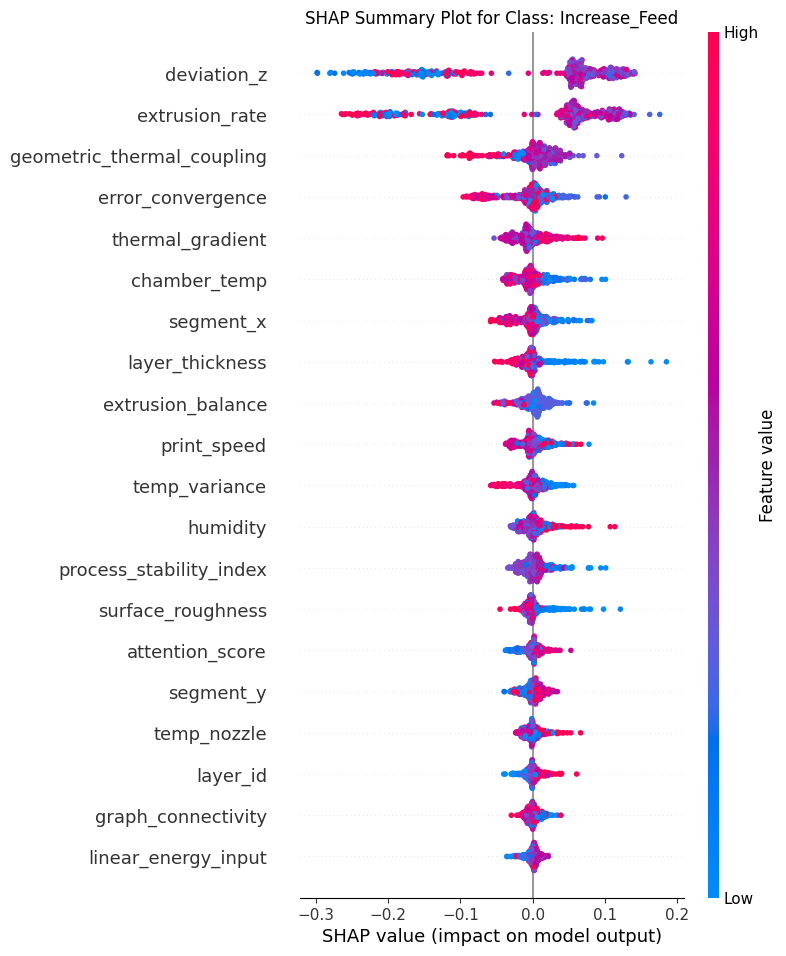


SHAP Summary Plot for Class: Increase_Speed


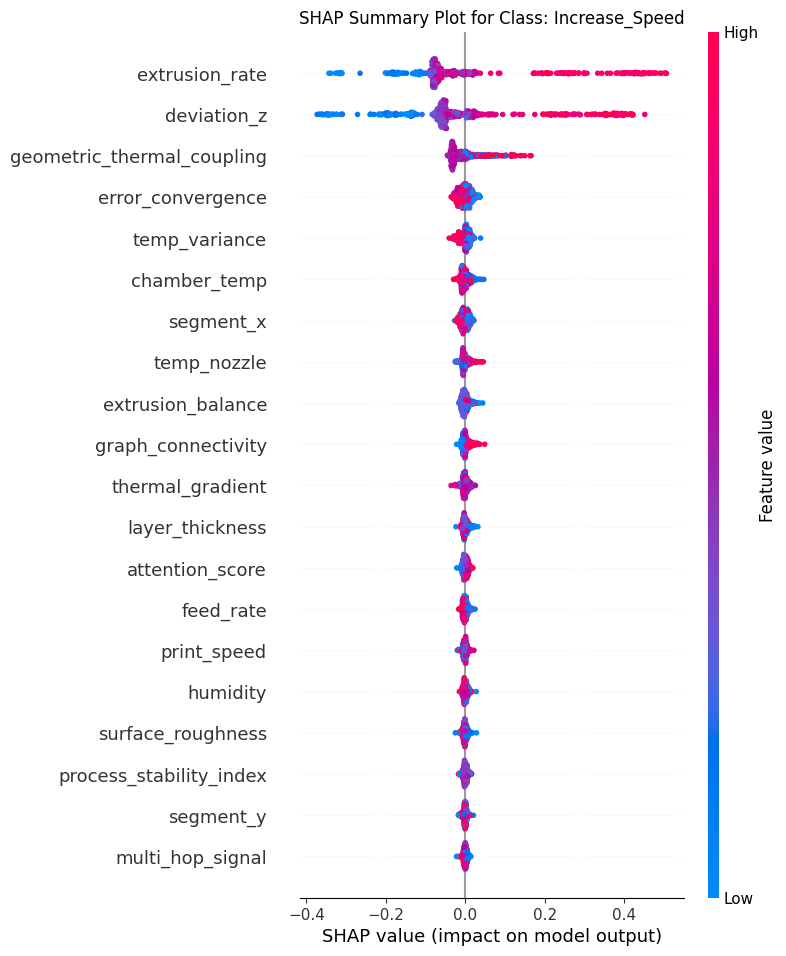


SHAP Summary Plot for Class: Unknown


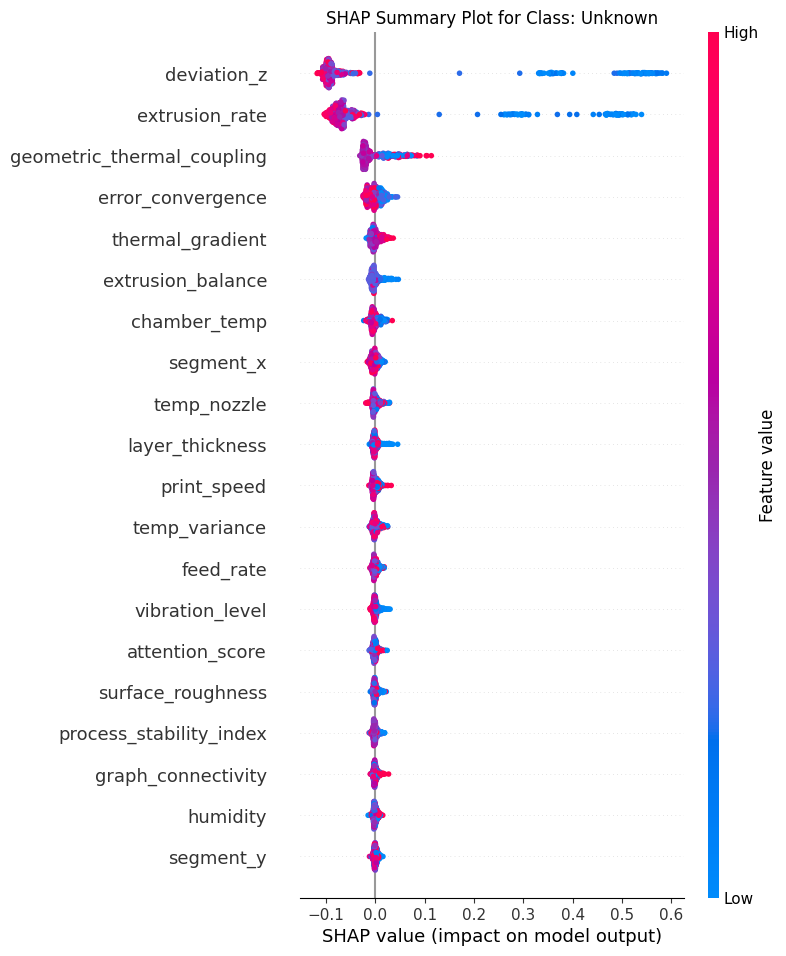

In [ ]:
# Map encoded labels back to original class names for better readability in plots
class_names = label_encoder.classes_

# Generate a summary plot for each class
for i, class_name in enumerate(class_names):
    print(f"\nSHAP Summary Plot for Class: {class_name}")
    # Correct slicing for 3D shap_values array: (num_samples, num_features) for class i
    shap.summary_plot(shap_values[:, :, i], X_test_new, plot_type="dot", show=False)
    plt.title(f"SHAP Summary Plot for Class: {class_name}")
    plt.show()

**SHAP Dependence**


SHAP Dependence Plots for Top Features:


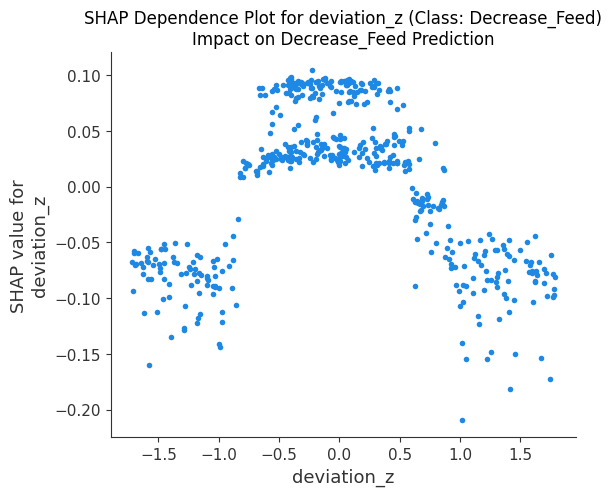

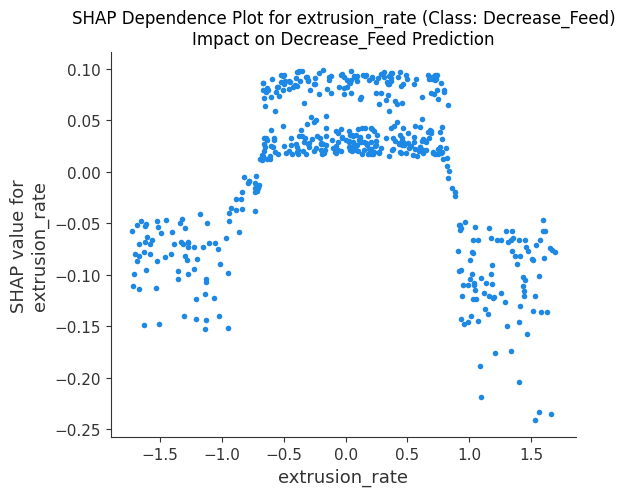

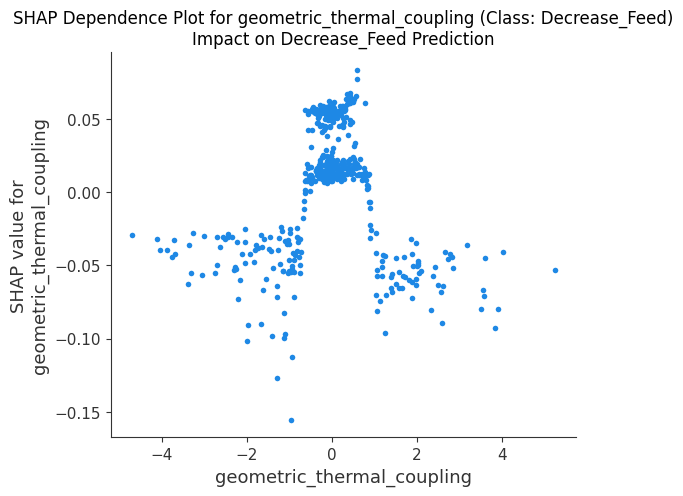

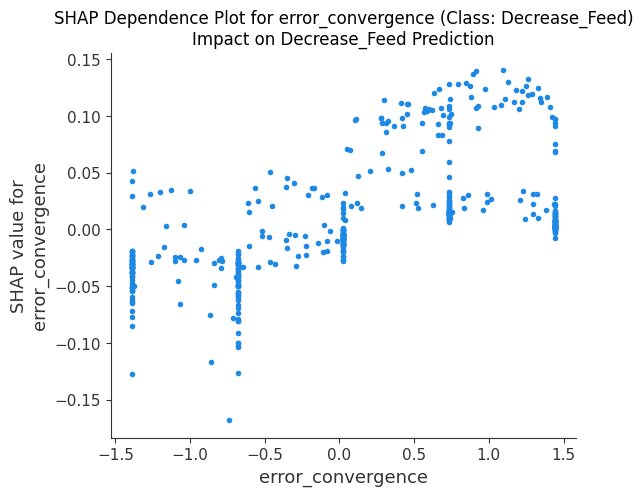

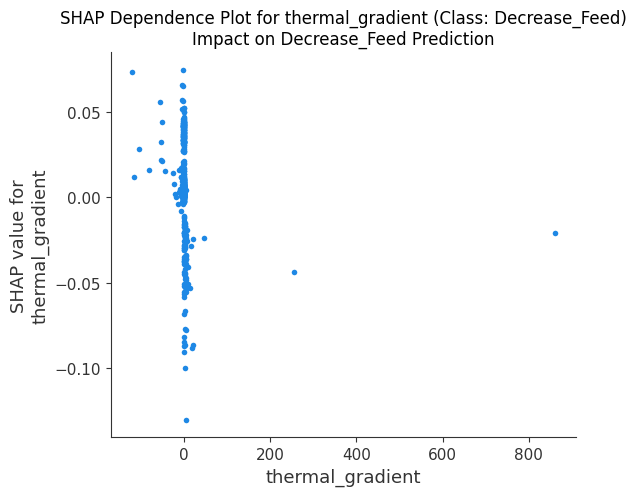

In [ ]:
# Get the overall top features from the previously calculated feature_importances_new
top_features = feature_importances_new['feature'].head(5).tolist()

# Generate dependence plots for the top features
print("\nSHAP Dependence Plots for Top Features:")
for feature in top_features:
    # Find the index of the feature in X_test_new.columns
    feature_idx = X_test_new.columns.get_loc(feature)

    # Correct slicing for 3D shap_values array: (num_samples, num_features) for class 0
    shap.dependence_plot(
        ind=feature, # Can also be X_test_new.columns.get_loc(feature)
        shap_values=shap_values[:, :, 0], # Assuming we are looking at SHAP values for class 0
        features=X_test_new,
        interaction_index=None, # Set to None for no interaction, or another feature name
        show=False # Prevent immediate display to allow custom title/layout
    )
    plt.title(f"SHAP Dependence Plot for {feature} (Class: {class_names[0]})\nImpact on {class_names[0]} Prediction")
    plt.show()